# Stable Period

In [1]:
import yfinance as yf
import pandas as pd

# Top 6 S&P 500 tickers
tickers = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META']

# Download adjusted close prices from 2017 to 2019
data = yf.download(tickers, start='2017-01-01', end='2019-12-31')['Close']
data.dropna(inplace=True)

data.to_csv('top6_stocks_2017_2019.csv')

print(data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  6 of 6 completed

Ticker           AAPL       AMZN      GOOGL        META       MSFT      NVDA
Date                                                                        
2017-01-03  26.827244  37.683498  40.208267  116.311821  56.497406  2.512663
2017-01-04  26.797216  37.859001  40.196323  118.133232  56.244621  2.571287
2017-01-05  26.933489  39.022499  40.457577  120.103951  56.244621  2.506013
2017-01-06  27.233757  39.799500  41.064175  122.831108  56.732132  2.539511
2017-01-09  27.483200  39.846001  41.162209  124.314110  56.551579  2.642471


In [2]:
stock_names = list(data.columns)
print(stock_names)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


In [3]:
import gym
import numpy as np

class MultiStockEnv6:
    """
    6-stock trading environment with discrete quantity control.
    Action space: 3 actions per stock (sell, hold, buy).
    State: [owned_1 to owned_6, price_1 to price_6, cash] → 13-dim vector.
    """

    def __init__(self, data, initial_investment=10000, stock_names=stock_names):
        self.stock_price_history = data.values
        self.n_step, self.n_stock = self.stock_price_history.shape
        self.initial_investment = initial_investment

        # Assign stock names or fallback to Stock 0, Stock 1, etc.
        self.stock_names = stock_names if stock_names else [f"Stock {i}" for i in range(self.n_stock)]

        # Action list: for each stock, do one of 3 actions
        self.action_list = []
        for i in range(self.n_stock):
            for a in [0, 1, 2]:  # 0=sell, 1=hold, 2=buy
                action = [1] * self.n_stock
                action[i] = a
                self.action_list.append(action)

        self.action_space = np.arange(len(self.action_list))
        self.state_dim = self.n_stock * 2 + 1
        self.reset()

    def reset(self):
        self.cur_step = 0
        self.stock_owned = np.zeros(self.n_stock, dtype=int)
        self.stock_price = self.stock_price_history[self.cur_step]
        self.cash_in_hand = self.initial_investment
        return self._get_obs()

    def step(self, action):
        assert action in self.action_space
        prev_val = self._get_val()

        self.cur_step += 1
        self.stock_price = self.stock_price_history[self.cur_step]
        self._trade(action)

        cur_val = self._get_val()
        reward = cur_val - prev_val
        done = self.cur_step == self.n_step - 1
        info = {'cur_val': cur_val}

        return self._get_obs(), reward, done, info

    def _get_obs(self):
        return np.concatenate([self.stock_owned, self.stock_price, [self.cash_in_hand]])

    def _get_val(self):
        return np.dot(self.stock_owned, self.stock_price) + self.cash_in_hand

    def _trade(self, action):
        action_vec = self.action_list[action]
        action_labels = {0: "Sell", 1: "Hold", 2: "Buy"}

        print(f"\n\033[1;36mStep {self.cur_step} — Cash Available: \033[95m${self.cash_in_hand:.2f}\033[0m")

        for i in range(self.n_stock):
            action_type = action_vec[i]
            price = self.stock_price[i]
            stock_name = self.stock_names[i]

            if action_type == 0:  # SELL (25% or 50%)
                owned = self.stock_owned[i]
                if owned > 0:
                    ratio = 0.25 if owned < 4 else 0.5
                    qty = int(owned * ratio)
                    if qty > 0:
                        self.stock_owned[i] -= qty
                        self.cash_in_hand += qty * price
                        print(f"\033[91m Sell {qty} of {stock_name} at ${price:.2f}\033[0m")
                    else:
                        print(f"⏸ Hold {stock_name}")
                else:
                    print(f"⏸ Hold {stock_name}")

            elif action_type == 2:  # BUY (25% or 50% of max)
                alloc_cash = self.cash_in_hand
                ratio = 0.25 if alloc_cash < 1000 else 0.5
                spend = alloc_cash * ratio
                qty = int(spend // price)
                if qty > 0:
                    self.stock_owned[i] += qty
                    self.cash_in_hand -= qty * price
                    print(f"\033[92m Buy {qty} of {stock_name} at ${price:.2f}\033[0m")
                else:
                    print(f"⏸ Hold {stock_name}")
            else:
                print(f"⏸ Hold {stock_name}")

In [4]:
#Build Linear Model

class LinearModel:
    def __init__(self, input_dim, n_action):
        self.W = np.random.randn(input_dim, n_action) / np.sqrt(input_dim)
        self.b = np.zeros(n_action)
        self.vW = 0
        self.vb = 0
        self.losses = []

    def predict(self, X):
        assert len(X.shape) == 2
        return X.dot(self.W) + self.b

    def sgd(self, X, Y, learning_rate=0.01, momentum=0.9):
        Yhat = self.predict(X)
        Yhat = np.clip(Yhat, -1e6, 1e6)
        Y = np.clip(Y, -1e6, 1e6)
        num_values = np.prod(Y.shape)
        gW = 2 * X.T.dot(Yhat - Y) / num_values
        gb = 2 * (Yhat - Y).sum(axis=0) / num_values

        self.vW = momentum * self.vW - learning_rate * gW
        self.vb = momentum * self.vb - learning_rate * gb
        self.W += self.vW
        self.b += self.vb

        mse = np.mean((Yhat - Y) ** 2)
        self.losses.append(mse)

In [5]:
#Create DQN Learning Agent

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = LinearModel(state_size, action_size)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.action_size)
        return np.argmax(self.model.predict(state)[0])

    def train(self, state, action, reward, next_state, done):
        target = reward if done else reward + self.gamma * np.max(self.model.predict(next_state))
        target_full = self.model.predict(state)
        target_full[0, action] = target
        self.model.sgd(state, target_full)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [6]:
#Normalize

from sklearn.preprocessing import StandardScaler

def get_scaler(env):
    states = []
    for _ in range(env.n_step - 1):
        action = np.random.choice(len(env.action_list))
        state, _, done, _ = env.step(action)
        states.append(state)
        if done:
            break
    scaler = StandardScaler()
    scaler.fit(states)
    return scaler

In [7]:
#Run single episode

def play_one_episode(agent, env, scaler, train=False):
    state = env.reset()
    state = scaler.transform([state])
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, info = env.step(action)
        next_state = scaler.transform([next_state])
        if train:
            agent.train(state, action, reward, next_state, done)
        state = next_state
    return info['cur_val']

In [8]:
# Split by updated date range
train_data = data.loc["2017-01-01":"2018-12-31"]
test_data = data.loc["2019-01-01":"2019-12-31"]

# Extract stock names from DataFrame columns
stock_names = list(data.columns)

# Confirm time periods
print("Training period:", train_data.index.min().date(), "to", train_data.index.max().date())
print("Test period    :", test_data.index.min().date(), "to", test_data.index.max().date())

Training period: 2017-01-03 to 2018-12-31
Test period    : 2019-01-02 to 2019-12-30


In [9]:
# Set up training environment and agent
env = MultiStockEnv6(train_data, initial_investment=10000, stock_names=stock_names)
state_size = env.state_dim
action_size = len(env.action_list)

agent = DQNAgent(state_size, action_size)
scaler = get_scaler(env)

# Train agent
num_episodes = 500
portfolio_values = []

for e in range(num_episodes):
    final_val = play_one_episode(agent, env, scaler, train=True)
    print(f"Episode {e+1}/{num_episodes} | Final Portfolio: ${final_val:.2f}")
    portfolio_values.append(final_val)

Streaming output truncated to the last 5000 lines.
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 379 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 380 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 381 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 382 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 383 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 384 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 385 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 386 — Cash Available: $4031.26
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold N

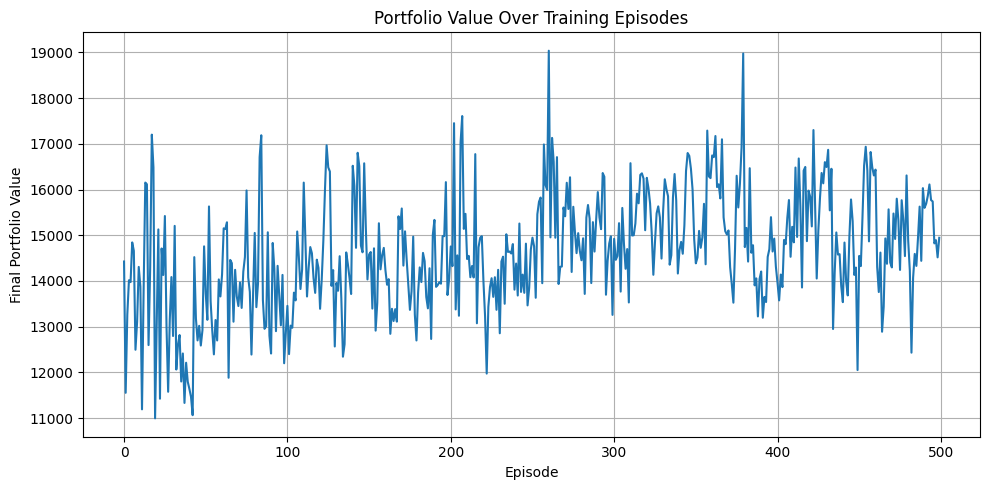

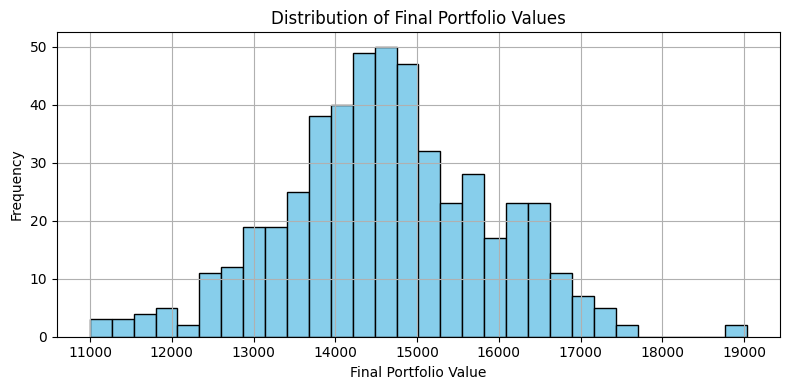

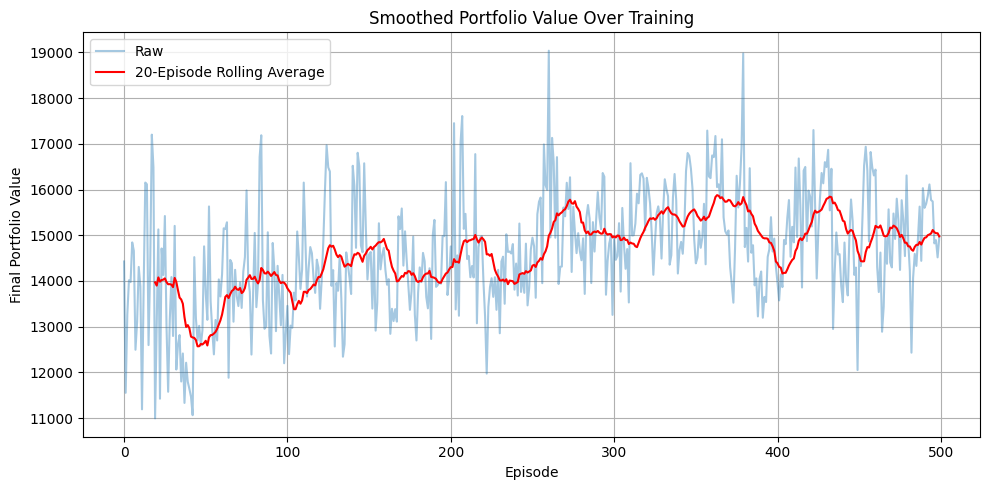

In [10]:
import matplotlib.pyplot as plt

#Portfolio Value Over Episodes
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values)
plt.title("Portfolio Value Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()

#Histogram of Final Portfolio Values
plt.figure(figsize=(8, 4))
plt.hist(portfolio_values, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#Rolling Average
window = 20
rolling_avg = pd.Series(portfolio_values).rolling(window).mean()

plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, alpha=0.4, label='Raw')
plt.plot(rolling_avg, color='red', label=f'{window}-Episode Rolling Average')
plt.title("Smoothed Portfolio Value Over Training")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Extract stock names from test data
stock_names = list(test_data.columns)

# Re-create test environment with stock_names
test_env = MultiStockEnv6(test_data, initial_investment=10000, stock_names=stock_names)

# Run one evaluation episode
final_val = play_one_episode(agent, test_env, scaler, train=False)
print(f"Final portfolio value on TEST data (2019): ${final_val:.2f}")


Step 1 — Cash Available: $10000.00
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 2 — Cash Available: $10000.00
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 3 — Cash Available: $10000.00
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 4 — Cash Available: $10000.00
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 5 — Cash Available: $10000.00
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 6 — Cash Available: $10000.00
 Buy 136 of AAPL at $36.64
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 7 — Cash Available: $5017.44
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 8 — Cash Available: $5017.44
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 9 — Cash Available: $5017.44
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 1

In [12]:
initial_cash = 10000
initial_prices = test_data.iloc[0].values
final_prices = test_data.iloc[-1].values

# Assume equal investment in each stock
weights = np.ones(len(initial_prices)) / len(initial_prices)
bh_return = final_prices / initial_prices
final_bh_value = initial_cash * np.dot(weights, bh_return)

print(f"Buy-and-Hold final portfolio value: ${final_bh_value:.2f}")

Buy-and-Hold final portfolio value: $15240.22


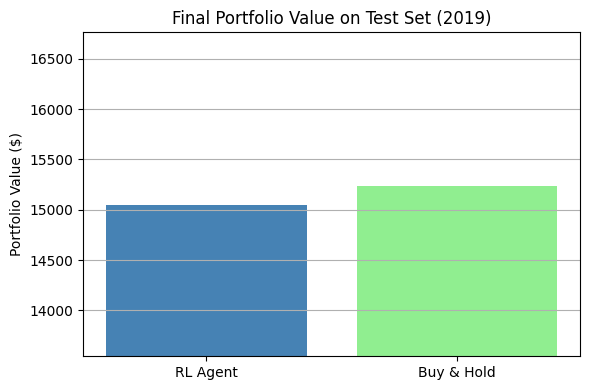

In [18]:
# Test results
rl_test_value = 15047.28
bh_test_value = 15240.22

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['RL Agent', 'Buy & Hold'], [rl_test_value, bh_test_value], color=['steelblue', 'lightgreen'])
plt.title("Final Portfolio Value on Test Set (2019)")
plt.ylabel("Portfolio Value ($)")
plt.ylim(min(rl_test_value, bh_test_value) * 0.9, max(rl_test_value, bh_test_value) * 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

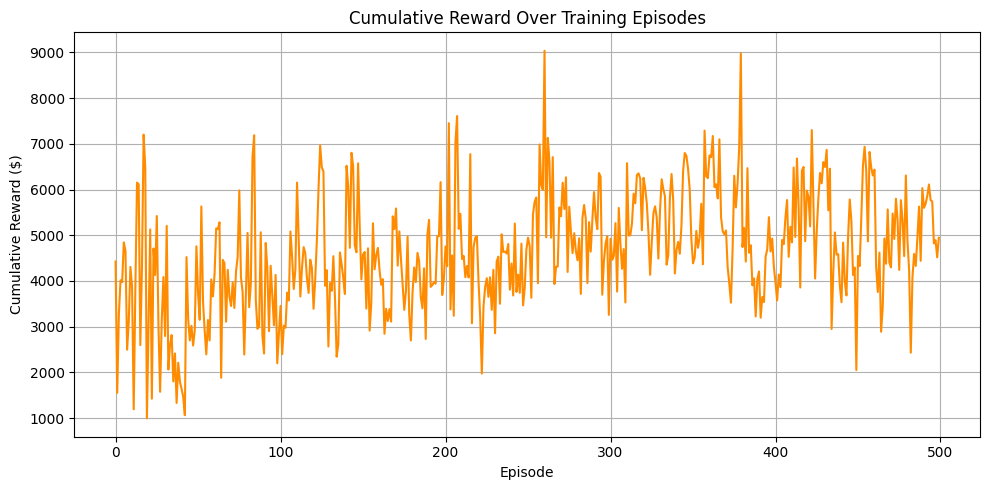

In [14]:
# Convert portfolio values into cumulative reward (change from episode to episode)
rewards = np.diff([10000] + portfolio_values)
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_rewards, color='darkorange')
plt.title("Cumulative Reward Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Define parameters for S&P 500 Benchmark
initial_cash = 10000
TEST_START = "2019-01-01"
TEST_END = "2019-12-31"

# Download S&P 500 Index (^GSPC = SPX)
spx_data = yf.download("^GSPC", start=TEST_START, end=TEST_END)["Close"]

# Ensure start/end values are float
spx_start = float(spy_data.iloc[0])
spx_end = float(spy_data.iloc[-1])

# Buy-and-hold return and final portfolio value
spx_return = spx_end / spx_start
spx_final_value = initial_cash * spy_return

print(f"Buy-and-Hold SPX final value: ${spx_final_value:.2f}")

[*********************100%***********************]  1 of 1 completed

Buy-and-Hold SPX final value: $12833.67



<ipython-input-24-e54caf420e99>:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spx_start = float(spy_data.iloc[0])
<ipython-input-24-e54caf420e99>:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spx_end = float(spy_data.iloc[-1])


In [25]:
rl_final_value = 15047.28

print(f"RL Agent final value: ${rl_final_value:.2f}")
print(f"SPX Buy-and-Hold final value: ${spx_final_value:.2f}")

rl_return = (rl_final_value - initial_cash) / initial_cash * 100
spx_return_pct = (spx_final_value - initial_cash) / initial_cash * 100

print(f"\n Comparison:")
print(f"RL Agent Return: {rl_return:.2f}%")
print(f"SPX Index Return: {spx_return_pct:.2f}%")

RL Agent final value: $15047.28
SPX Buy-and-Hold final value: $12833.67

 Comparison:
RL Agent Return: 50.47%
SPX Index Return: 28.34%


# Financial Crisis

In [26]:
# Adjusted tickers for 2007-2009 data
tickers = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL']

# Download adjusted close prices from Oct 2007 to Dec 2009
data = yf.download(tickers, start='2007-10-01', end='2009-12-31')['Close']
data.dropna(inplace=True)

# Save to CSV
data.to_csv('top6_stocks_2007_2009.csv')

# Display preview
print(data.head())

[*********************100%***********************]  5 of 5 completed

Ticker          AAPL    AMZN      GOOGL       MSFT      NVDA
Date                                                        
2007-10-01  4.698673  4.6705  14.508962  21.349043  0.865878
2007-10-02  4.762087  4.6180  14.554790  21.298845  0.857625
2007-10-03  4.746158  4.6230  14.545574  21.119553  0.821174
2007-10-04  4.695667  4.6130  14.421292  21.306007  0.824842
2007-10-05  4.852248  4.6715  14.795380  21.399240  0.846621


In [27]:
stock_names = list(data.columns)
print(stock_names)

['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']


In [28]:
class MultiStockEnv6:
    """
    6-stock trading environment with discrete quantity control.
    Action space: 3 actions per stock (sell, hold, buy).
    State: [owned_1 to owned_6, price_1 to price_6, cash] → 13-dim vector.
    """

    def __init__(self, data, initial_investment=10000, stock_names=stock_names):
        self.stock_price_history = data.values
        self.n_step, self.n_stock = self.stock_price_history.shape
        self.initial_investment = initial_investment

        # Assign stock names or fallback to Stock 0, Stock 1, etc.
        self.stock_names = stock_names if stock_names else [f"Stock {i}" for i in range(self.n_stock)]

        # Action list: for each stock, do one of 3 actions
        self.action_list = []
        for i in range(self.n_stock):
            for a in [0, 1, 2]:  # 0=sell, 1=hold, 2=buy
                action = [1] * self.n_stock
                action[i] = a
                self.action_list.append(action)

        self.action_space = np.arange(len(self.action_list))
        self.state_dim = self.n_stock * 2 + 1
        self.reset()

    def reset(self):
        self.cur_step = 0
        self.stock_owned = np.zeros(self.n_stock, dtype=int)
        self.stock_price = self.stock_price_history[self.cur_step]
        self.cash_in_hand = self.initial_investment
        return self._get_obs()

    def step(self, action):
        assert action in self.action_space
        prev_val = self._get_val()

        self.cur_step += 1
        self.stock_price = self.stock_price_history[self.cur_step]
        self._trade(action)

        cur_val = self._get_val()
        reward = cur_val - prev_val
        done = self.cur_step == self.n_step - 1
        info = {'cur_val': cur_val}

        return self._get_obs(), reward, done, info

    def _get_obs(self):
        return np.concatenate([self.stock_owned, self.stock_price, [self.cash_in_hand]])

    def _get_val(self):
        return np.dot(self.stock_owned, self.stock_price) + self.cash_in_hand

    def _trade(self, action):
        action_vec = self.action_list[action]
        action_labels = {0: "Sell", 1: "Hold", 2: "Buy"}

        print(f"\n\033[1;36mStep {self.cur_step} — Cash Available: \033[95m${self.cash_in_hand:.2f}\033[0m")

        for i in range(self.n_stock):
            action_type = action_vec[i]
            price = self.stock_price[i]
            stock_name = self.stock_names[i]

            if action_type == 0:  # SELL (25% or 50%)
                owned = self.stock_owned[i]
                if owned > 0:
                    ratio = 0.25 if owned < 4 else 0.5
                    qty = int(owned * ratio)
                    if qty > 0:
                        self.stock_owned[i] -= qty
                        self.cash_in_hand += qty * price
                        print(f"\033[91m Sell {qty} of {stock_name} at ${price:.2f}\033[0m")
                    else:
                        print(f"⏸ Hold {stock_name}")
                else:
                    print(f"⏸ Hold {stock_name}")

            elif action_type == 2:  # BUY (25% or 50% of max)
                alloc_cash = self.cash_in_hand
                ratio = 0.25 if alloc_cash < 1000 else 0.5
                spend = alloc_cash * ratio
                qty = int(spend // price)
                if qty > 0:
                    self.stock_owned[i] += qty
                    self.cash_in_hand -= qty * price
                    print(f"\033[92m Buy {qty} of {stock_name} at ${price:.2f}\033[0m")
                else:
                    print(f"⏸ Hold {stock_name}")
            else:
                print(f"⏸ Hold {stock_name}")

In [29]:
#Build Linear Model

class LinearModel:
    def __init__(self, input_dim, n_action):
        self.W = np.random.randn(input_dim, n_action) / np.sqrt(input_dim)
        self.b = np.zeros(n_action)
        self.vW = 0
        self.vb = 0
        self.losses = []

    def predict(self, X):
        assert len(X.shape) == 2
        return X.dot(self.W) + self.b

    def sgd(self, X, Y, learning_rate=0.01, momentum=0.9):
        Yhat = self.predict(X)
        Yhat = np.clip(Yhat, -1e6, 1e6)
        Y = np.clip(Y, -1e6, 1e6)
        num_values = np.prod(Y.shape)
        gW = 2 * X.T.dot(Yhat - Y) / num_values
        gb = 2 * (Yhat - Y).sum(axis=0) / num_values

        self.vW = momentum * self.vW - learning_rate * gW
        self.vb = momentum * self.vb - learning_rate * gb
        self.W += self.vW
        self.b += self.vb

        mse = np.mean((Yhat - Y) ** 2)
        self.losses.append(mse)

In [30]:
#Create DQN Learning Agent

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = LinearModel(state_size, action_size)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.action_size)
        return np.argmax(self.model.predict(state)[0])

    def train(self, state, action, reward, next_state, done):
        target = reward if done else reward + self.gamma * np.max(self.model.predict(next_state))
        target_full = self.model.predict(state)
        target_full[0, action] = target
        self.model.sgd(state, target_full)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [31]:
#Normalize

from sklearn.preprocessing import StandardScaler

def get_scaler(env):
    states = []
    for _ in range(env.n_step - 1):
        action = np.random.choice(len(env.action_list))
        state, _, done, _ = env.step(action)
        states.append(state)
        if done:
            break
    scaler = StandardScaler()
    scaler.fit(states)
    return scaler

In [32]:
#Run single episode

def play_one_episode(agent, env, scaler, train=False):
    state = env.reset()
    state = scaler.transform([state])
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, info = env.step(action)
        next_state = scaler.transform([next_state])
        if train:
            agent.train(state, action, reward, next_state, done)
        state = next_state
    return info['cur_val']

In [33]:
# Split by updated date range
train_data = data.loc['2007-10-01':'2009-03-31']
test_data = data.loc['2009-04-01':'2009-12-31']

# Extract stock names from DataFrame columns
stock_names = list(data.columns)

# Confirm time periods
print("Training period:", train_data.index.min().date(), "to", train_data.index.max().date())
print("Test period    :", test_data.index.min().date(), "to", test_data.index.max().date())

# Set up training environment and agent
env = MultiStockEnv6(train_data, initial_investment=10000, stock_names=stock_names)
state_size = env.state_dim
action_size = len(env.action_list)

agent = DQNAgent(state_size, action_size)
scaler = get_scaler(env)

# Train agent
num_episodes = 500
portfolio_values = []

for e in range(num_episodes):
    final_val = play_one_episode(agent, env, scaler, train=True)
    print(f"Episode {e+1}/{num_episodes} | Final Portfolio: ${final_val:.2f}")
    portfolio_values.append(final_val)

Streaming output truncated to the last 5000 lines.

Step 41 — Cash Available: $7532.13
 Sell 104 of AAPL at $5.42
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 42 — Cash Available: $8095.43
 Sell 52 of AAPL at $5.54
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 43 — Cash Available: $8383.45
 Sell 26 of AAPL at $5.48
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 44 — Cash Available: $8525.83
 Sell 13 of AAPL at $5.38
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 45 — Cash Available: $8595.72
 Sell 6 of AAPL at $5.40
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 46 — Cash Available: $8628.14
 Sell 3 of AAPL at $5.58
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 47 — Cash Available: $8644.86
 Sell 2 of AAPL at $5.71
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 48 — Cash Available: $8656.28
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 49 — Cash Available: $8656.28
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Ho

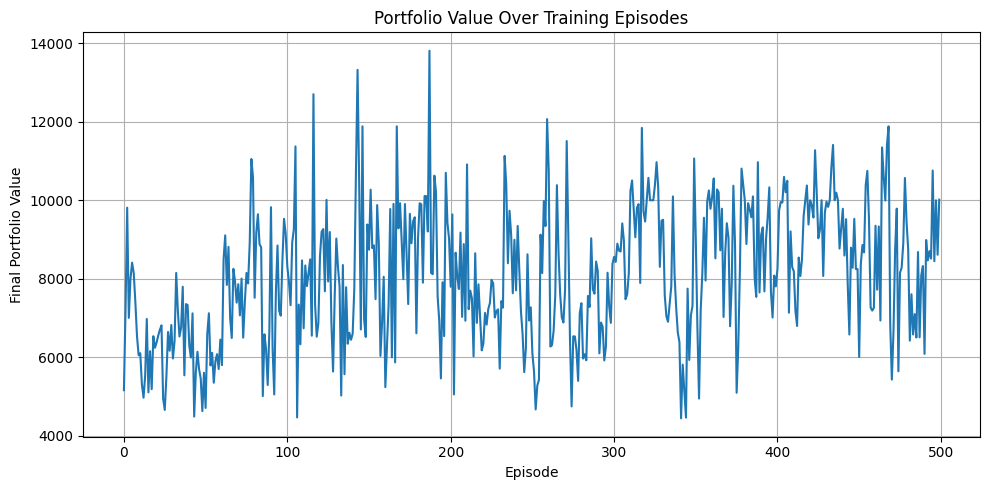

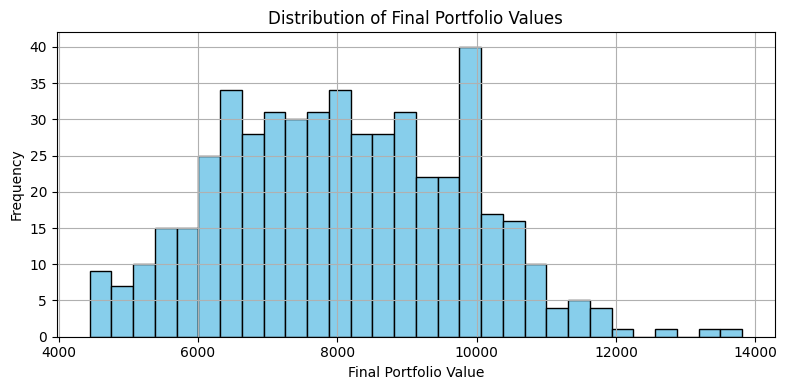

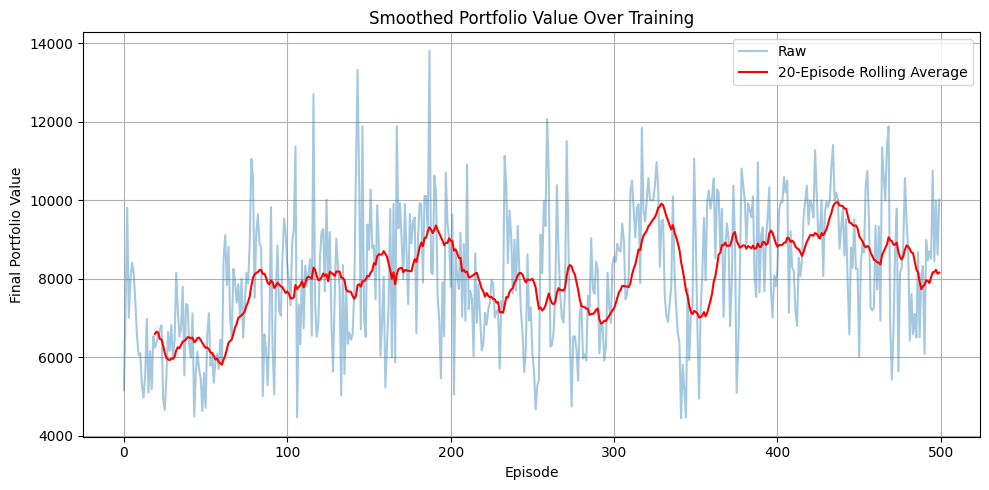

In [34]:
import matplotlib.pyplot as plt

#Portfolio Value Over Episodes
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values)
plt.title("Portfolio Value Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()

#Histogram of Final Portfolio Values
plt.figure(figsize=(8, 4))
plt.hist(portfolio_values, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#Rolling Average
window = 20
rolling_avg = pd.Series(portfolio_values).rolling(window).mean()

plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, alpha=0.4, label='Raw')
plt.plot(rolling_avg, color='red', label=f'{window}-Episode Rolling Average')
plt.title("Smoothed Portfolio Value Over Training")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Extract stock names from test data
stock_names = list(test_data.columns)

# Re-create test environment with stock_names
test_env = MultiStockEnv6(test_data, initial_investment=10000, stock_names=stock_names)

# Run one evaluation episode
final_val = play_one_episode(agent, test_env, scaler, train=False)
print(f"Final portfolio value on TEST data (2009): ${final_val:.2f}")


Step 1 — Cash Available: $10000.00
 Buy 1476 of AAPL at $3.39
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 2 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 3 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 4 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 5 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 6 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 7 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 8 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 9 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 10 — Cash Available: $5000.19
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold MSFT
⏸ Hold NVDA

Step 11 — Cash Availab

In [36]:
initial_cash = 10000
initial_prices = test_data.iloc[0].values
final_prices = test_data.iloc[-1].values

# Assume equal investment in each stock
weights = np.ones(len(initial_prices)) / len(initial_prices)
bh_return = final_prices / initial_prices
final_bh_value = initial_cash * np.dot(weights, bh_return)

print(f"Buy-and-Hold final portfolio value: ${final_bh_value:.2f}")

Buy-and-Hold final portfolio value: $18078.60


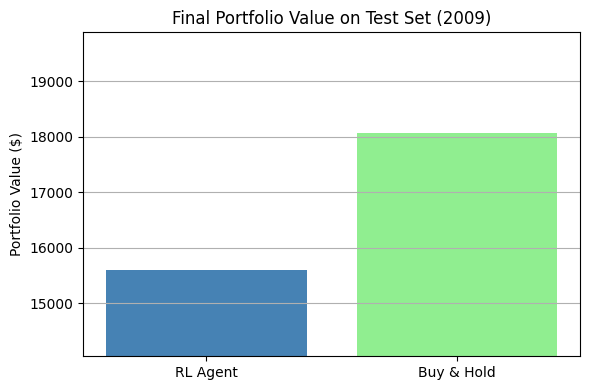

In [42]:
# Test results
rl_test_value = 15605.34
bh_test_value = 18078.60

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['RL Agent', 'Buy & Hold'], [rl_test_value, bh_test_value], color=['steelblue', 'lightgreen'])
plt.title("Final Portfolio Value on Test Set (2009)")
plt.ylabel("Portfolio Value ($)")
plt.ylim(min(rl_test_value, bh_test_value) * 0.9, max(rl_test_value, bh_test_value) * 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

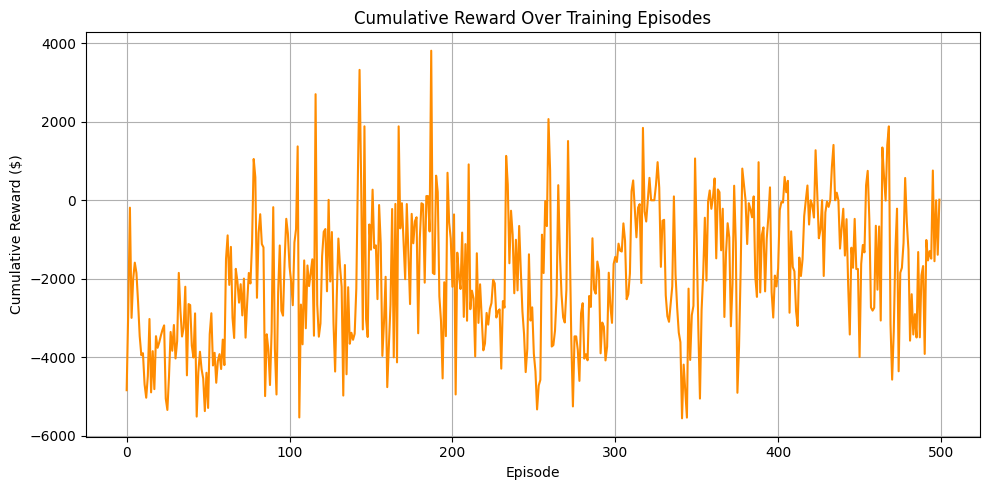

In [38]:
# Convert portfolio values into cumulative reward (change from episode to episode)
rewards = np.diff([10000] + portfolio_values)
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_rewards, color='darkorange')
plt.title("Cumulative Reward Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Define parameters for S&P 500 Benchmark
initial_cash = 10000
TEST_START = "2009-04-01"
TEST_END = "2009-12-31"

# Download S&P 500 Index (^GSPC = SPX)
spy_data = yf.download("^GSPC", start=TEST_START, end=TEST_END)["Close"]

# Ensure start/end values are float
spy_start = float(spy_data.iloc[0])
spy_end = float(spy_data.iloc[-1])

# Buy-and-hold return and final portfolio value
spy_return = spy_end / spy_start
spy_final_value = initial_cash * spy_return

print(f"Buy-and-Hold SPX final value: ${spy_final_value:.2f}")

[*********************100%***********************]  1 of 1 completed

Buy-and-Hold SPX final value: $13887.90



<ipython-input-43-efbd59f7d8e8>:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_start = float(spy_data.iloc[0])
<ipython-input-43-efbd59f7d8e8>:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_end = float(spy_data.iloc[-1])


In [44]:
rl_final_value = 15605.34

print(f"RL Agent final value: ${rl_final_value:.2f}")
print(f"SPY Buy-and-Hold final value: ${spy_final_value:.2f}")

rl_return = (rl_final_value - initial_cash) / initial_cash * 100
spy_return_pct = (spy_final_value - initial_cash) / initial_cash * 100

print(f"\n Comparison:")
print(f"RL Agent Return: {rl_return:.2f}%")
print(f"SPY Index Return: {spy_return_pct:.2f}%")

RL Agent final value: $15605.34
SPY Buy-and-Hold final value: $13887.90

 Comparison:
RL Agent Return: 56.05%
SPY Index Return: 38.88%


# Covid-19 Crisis

In [45]:
# Top 6 S&P 500 tickers
tickers = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META']

# Download adjusted close prices from 2020 to 2023
data = yf.download(tickers, start='2020-01-01', end='2023-12-31')['Close']
data.dropna(inplace=True)

# Save full data
data.to_csv('top6_stocks_2020_2023.csv')

# Display preview
print(data.head())

[*********************100%***********************]  6 of 6 completed

Ticker           AAPL       AMZN      GOOGL        META        MSFT      NVDA
Date                                                                         
2020-01-02  72.620834  94.900497  68.108376  208.795914  153.042267  5.972161
2020-01-03  71.914818  93.748497  67.752083  207.691147  151.136658  5.876571
2020-01-06  72.487854  95.143997  69.557945  211.602722  151.527328  5.901216
2020-01-07  72.146942  95.343002  69.423592  212.060562  150.145737  5.972659
2020-01-08  73.307510  94.598503  69.917732  214.210434  152.537338  5.983861


In [46]:
stock_names = list(data.columns)
print(stock_names)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


In [47]:
import gym
import numpy as np

class MultiStockEnv6:
    """
    6-stock trading environment with discrete quantity control.
    Action space: 3 actions per stock (sell, hold, buy).
    State: [owned_1 to owned_6, price_1 to price_6, cash] → 13-dim vector.
    """

    def __init__(self, data, initial_investment=10000, stock_names=stock_names):
        self.stock_price_history = data.values
        self.n_step, self.n_stock = self.stock_price_history.shape
        self.initial_investment = initial_investment

        # Assign stock names or fallback to Stock 0, Stock 1, etc.
        self.stock_names = stock_names if stock_names else [f"Stock {i}" for i in range(self.n_stock)]

        # Action list: for each stock, do one of 3 actions
        self.action_list = []
        for i in range(self.n_stock):
            for a in [0, 1, 2]:  # 0=sell, 1=hold, 2=buy
                action = [1] * self.n_stock
                action[i] = a
                self.action_list.append(action)

        self.action_space = np.arange(len(self.action_list))
        self.state_dim = self.n_stock * 2 + 1
        self.reset()

    def reset(self):
        self.cur_step = 0
        self.stock_owned = np.zeros(self.n_stock, dtype=int)
        self.stock_price = self.stock_price_history[self.cur_step]
        self.cash_in_hand = self.initial_investment
        return self._get_obs()

    def step(self, action):
        assert action in self.action_space
        prev_val = self._get_val()

        self.cur_step += 1
        self.stock_price = self.stock_price_history[self.cur_step]
        self._trade(action)

        cur_val = self._get_val()
        reward = cur_val - prev_val
        done = self.cur_step == self.n_step - 1
        info = {'cur_val': cur_val}

        return self._get_obs(), reward, done, info

    def _get_obs(self):
        return np.concatenate([self.stock_owned, self.stock_price, [self.cash_in_hand]])

    def _get_val(self):
        return np.dot(self.stock_owned, self.stock_price) + self.cash_in_hand

    def _trade(self, action):
        action_vec = self.action_list[action]
        action_labels = {0: "Sell", 1: "Hold", 2: "Buy"}

        print(f"\n\033[1;36mStep {self.cur_step} — Cash Available: \033[95m${self.cash_in_hand:.2f}\033[0m")

        for i in range(self.n_stock):
            action_type = action_vec[i]
            price = self.stock_price[i]
            stock_name = self.stock_names[i]

            if action_type == 0:  # SELL (25% or 50%)
                owned = self.stock_owned[i]
                if owned > 0:
                    ratio = 0.25 if owned < 4 else 0.5
                    qty = int(owned * ratio)
                    if qty > 0:
                        self.stock_owned[i] -= qty
                        self.cash_in_hand += qty * price
                        print(f"\033[91m Sell {qty} of {stock_name} at ${price:.2f}\033[0m")
                    else:
                        print(f"⏸ Hold {stock_name}")
                else:
                    print(f"⏸ Hold {stock_name}")

            elif action_type == 2:  # BUY (25% or 50% of max)
                alloc_cash = self.cash_in_hand
                ratio = 0.25 if alloc_cash < 1000 else 0.5
                spend = alloc_cash * ratio
                qty = int(spend // price)
                if qty > 0:
                    self.stock_owned[i] += qty
                    self.cash_in_hand -= qty * price
                    print(f"\033[92m Buy {qty} of {stock_name} at ${price:.2f}\033[0m")
                else:
                    print(f"⏸ Hold {stock_name}")
            else:
                print(f"⏸ Hold {stock_name}")

In [48]:
#Build Linear Model

class LinearModel:
    def __init__(self, input_dim, n_action):
        self.W = np.random.randn(input_dim, n_action) / np.sqrt(input_dim)
        self.b = np.zeros(n_action)
        self.vW = 0
        self.vb = 0
        self.losses = []

    def predict(self, X):
        assert len(X.shape) == 2
        return X.dot(self.W) + self.b

    def sgd(self, X, Y, learning_rate=0.01, momentum=0.9):
        Yhat = self.predict(X)
        Yhat = np.clip(Yhat, -1e6, 1e6)
        Y = np.clip(Y, -1e6, 1e6)
        num_values = np.prod(Y.shape)
        gW = 2 * X.T.dot(Yhat - Y) / num_values
        gb = 2 * (Yhat - Y).sum(axis=0) / num_values

        self.vW = momentum * self.vW - learning_rate * gW
        self.vb = momentum * self.vb - learning_rate * gb
        self.W += self.vW
        self.b += self.vb

        mse = np.mean((Yhat - Y) ** 2)
        self.losses.append(mse)

In [49]:
#Create DQN Learning Agent

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = LinearModel(state_size, action_size)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.action_size)
        return np.argmax(self.model.predict(state)[0])

    def train(self, state, action, reward, next_state, done):
        target = reward if done else reward + self.gamma * np.max(self.model.predict(next_state))
        target_full = self.model.predict(state)
        target_full[0, action] = target
        self.model.sgd(state, target_full)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [50]:
#Normalize

from sklearn.preprocessing import StandardScaler

def get_scaler(env):
    states = []
    for _ in range(env.n_step - 1):
        action = np.random.choice(len(env.action_list))
        state, _, done, _ = env.step(action)
        states.append(state)
        if done:
            break
    scaler = StandardScaler()
    scaler.fit(states)
    return scaler

In [51]:
#Run single episode

def play_one_episode(agent, env, scaler, train=False):
    state = env.reset()
    state = scaler.transform([state])
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, info = env.step(action)
        next_state = scaler.transform([next_state])
        if train:
            agent.train(state, action, reward, next_state, done)
        state = next_state
    return info['cur_val']

In [52]:
# Split by updated date range
train_data = data.loc['2020-01-01':'2022-12-31']
test_data = data.loc['2023-01-01':'2023-12-31']

# Extract stock names from DataFrame columns
stock_names = list(data.columns)

# Confirm time periods
print("Training period:", train_data.index.min().date(), "to", train_data.index.max().date())
print("Test period    :", test_data.index.min().date(), "to", test_data.index.max().date())

Training period: 2020-01-02 to 2022-12-30
Test period    : 2023-01-03 to 2023-12-29


In [53]:
# Set up training environment and agent
env = MultiStockEnv6(train_data, initial_investment=10000, stock_names=stock_names)
state_size = env.state_dim
action_size = len(env.action_list)

agent = DQNAgent(state_size, action_size)
scaler = get_scaler(env)

# Train agent
num_episodes = 500
portfolio_values = []

for e in range(num_episodes):
    final_val = play_one_episode(agent, env, scaler, train=True)
    print(f"Episode {e+1}/{num_episodes} | Final Portfolio: ${final_val:.2f}")
    portfolio_values.append(final_val)

Streaming output truncated to the last 5000 lines.
Step 131 — Cash Available: $800.06
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 132 — Cash Available: $800.06
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 133 — Cash Available: $800.06
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 134 — Cash Available: $800.06
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 135 — Cash Available: $800.06
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
 Sell 12 of MSFT at $195.37
⏸ Hold NVDA

Step 136 — Cash Available: $3144.54
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
 Buy 8 of MSFT at $194.38
⏸ Hold NVDA

Step 137 — Cash Available: $1589.53
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
 Buy 3 of MSFT at $202.73
⏸ Hold NVDA

Step 138 — Cash Available: $981.33
⏸ Hold AAPL
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 139 — Cash Available: $981

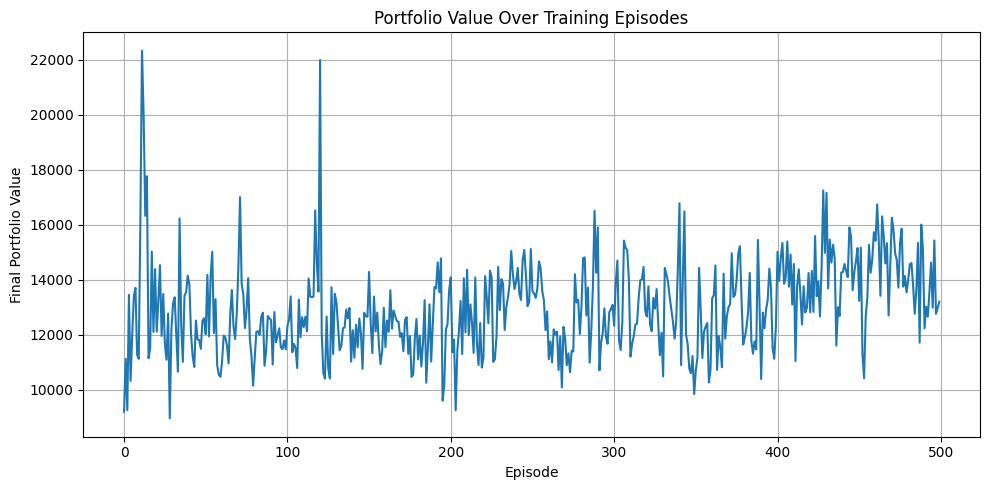

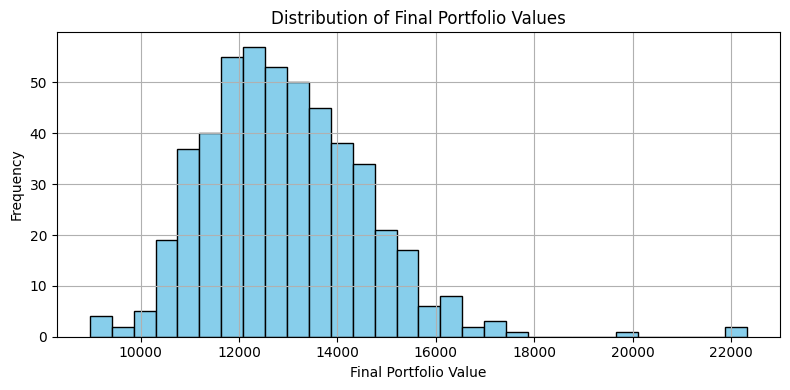

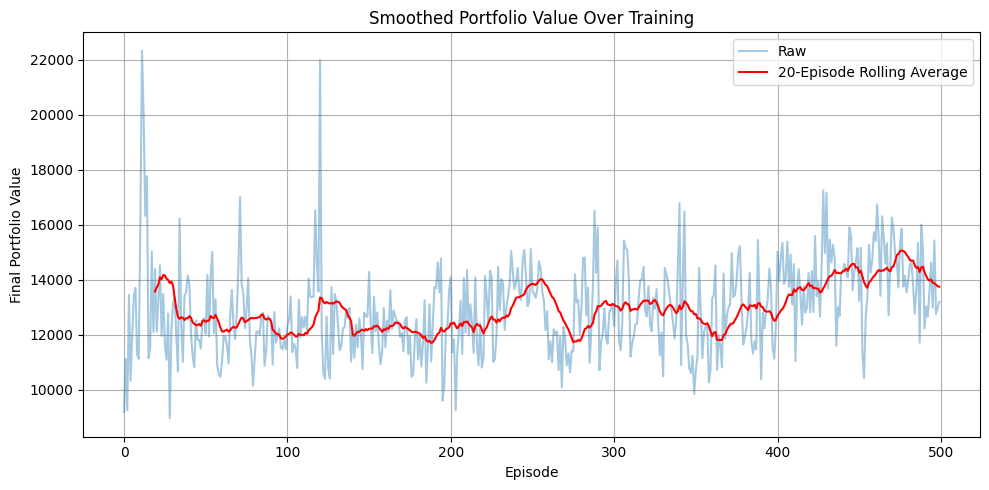

In [54]:
#Portfolio Value Over Episodes
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values)
plt.title("Portfolio Value Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()

#Histogram of Final Portfolio Values
plt.figure(figsize=(8, 4))
plt.hist(portfolio_values, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#Rolling Average
window = 20
rolling_avg = pd.Series(portfolio_values).rolling(window).mean()

plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, alpha=0.4, label='Raw')
plt.plot(rolling_avg, color='red', label=f'{window}-Episode Rolling Average')
plt.title("Smoothed Portfolio Value Over Training")
plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
# Extract stock names from test data
stock_names = list(test_data.columns)

# Re-create test environment with stock_names
test_env = MultiStockEnv6(test_data, initial_investment=10000, stock_names=stock_names)

# Run one evaluation episode
final_val = play_one_episode(agent, test_env, scaler, train=False)
print(f"Final portfolio value on TEST data (2023): ${final_val:.2f}")


Step 1 — Cash Available: $10000.00
 Buy 40 of AAPL at $124.74
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 2 — Cash Available: $5010.24
 Buy 20 of AAPL at $123.42
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 3 — Cash Available: $2541.81
 Buy 9 of AAPL at $127.96
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 4 — Cash Available: $1390.15
 Sell 34 of AAPL at $128.49
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 5 — Cash Available: $5758.66
 Buy 22 of AAPL at $129.06
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 6 — Cash Available: $2919.38
 Buy 11 of AAPL at $131.78
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 7 — Cash Available: $1469.77
 Buy 5 of AAPL at $131.70
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 8 — Cash Available: $811.25
 Sell 36 of AAPL at $133.04
⏸ Hold AMZN
⏸ Hold GOOGL
⏸ Hold META
⏸ Hold MSFT
⏸ Hold NVDA

Step 9 — Cash A

In [56]:
initial_cash = 10000
initial_prices = test_data.iloc[0].values
final_prices = test_data.iloc[-1].values

# Assume equal investment in each stock
weights = np.ones(len(initial_prices)) / len(initial_prices)
bh_return = final_prices / initial_prices
final_bh_value = initial_cash * np.dot(weights, bh_return)

print(f"Buy-and-Hold final portfolio value: ${final_bh_value:.2f}")

Buy-and-Hold final portfolio value: $21279.89


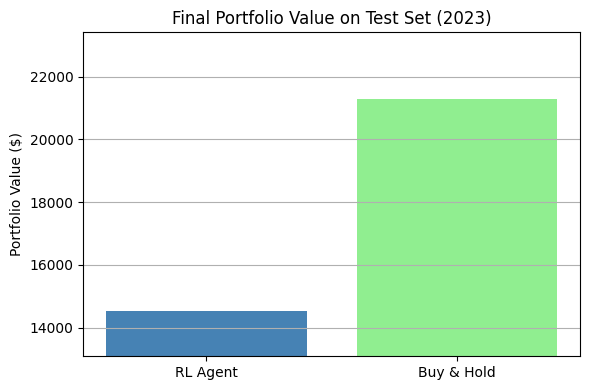

In [62]:
# Test results
rl_test_value = 14544.07
bh_test_value = 21279.89

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['RL Agent', 'Buy & Hold'], [rl_test_value, bh_test_value], color=['steelblue', 'lightgreen'])
plt.title("Final Portfolio Value on Test Set (2023)")
plt.ylabel("Portfolio Value ($)")
plt.ylim(min(rl_test_value, bh_test_value) * 0.9, max(rl_test_value, bh_test_value) * 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

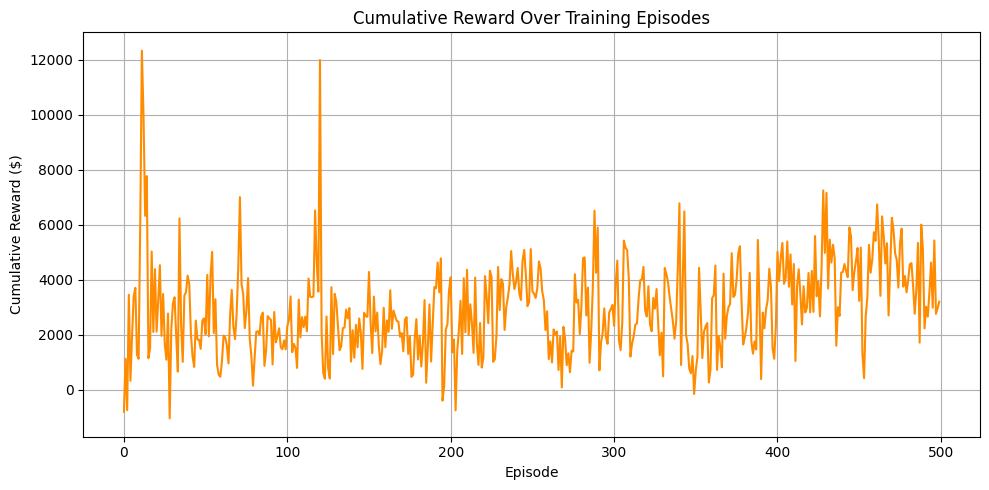

In [58]:
# Convert portfolio values into cumulative reward (change from episode to episode)
rewards = np.diff([10000] + portfolio_values)
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_rewards, color='darkorange')
plt.title("Cumulative Reward Over Training Episodes")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# Define parameters for S&P500 Benchmark
initial_cash = 10000
TEST_START = "2023-01-01"
TEST_END = "2023-12-31"

# Download S&P 500 Index (^GSPC = SPX)
spy_data = yf.download("^GSPC", start=TEST_START, end=TEST_END)["Close"]

# Ensure start/end values are float
spy_start = float(spy_data.iloc[0])
spy_end = float(spy_data.iloc[-1])

# Buy-and-hold return and final portfolio value
spy_return = spy_end / spy_start
spy_final_value = initial_cash * spy_return

print(f"Buy-and-Hold SPX final value: ${spy_final_value:.2f}")

[*********************100%***********************]  1 of 1 completed

Buy-and-Hold SPX final value: $12472.95



<ipython-input-63-7b2a79b3ac91>:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_start = float(spy_data.iloc[0])
<ipython-input-63-7b2a79b3ac91>:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_end = float(spy_data.iloc[-1])


In [64]:
rl_final_value = 14544.07

print(f"RL Agent final value: ${rl_final_value:.2f}")
print(f"SPY Buy-and-Hold final value: ${spy_final_value:.2f}")

rl_return = (rl_final_value - initial_cash) / initial_cash * 100
spy_return_pct = (spy_final_value - initial_cash) / initial_cash * 100

print(f"\n Comparison:")
print(f"RL Agent Return: {rl_return:.2f}%")
print(f"SPY Index Return: {spy_return_pct:.2f}%")

RL Agent final value: $14544.07
SPY Buy-and-Hold final value: $12472.95

 Comparison:
RL Agent Return: 45.44%
SPY Index Return: 24.73%


#Overall Comparison

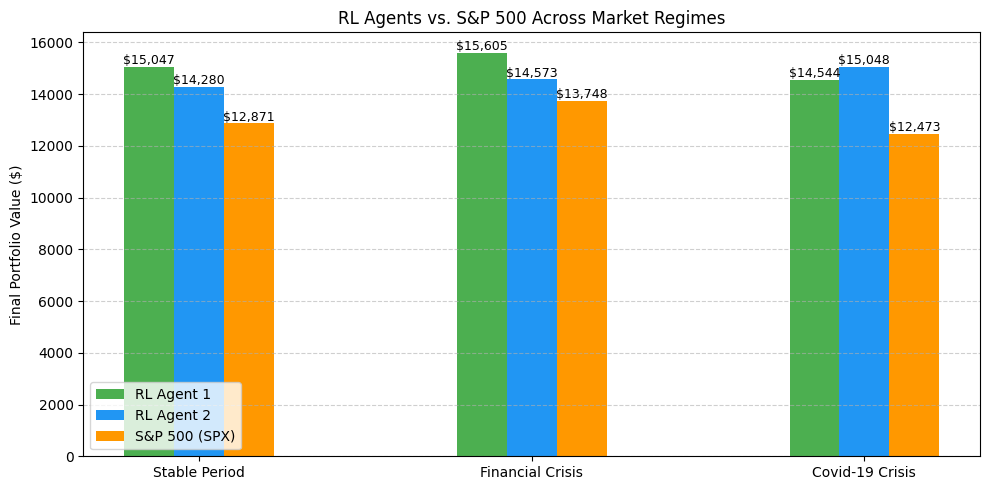

In [68]:
# Define data
periods = ['Stable Period', 'Financial Crisis', 'Covid-19 Crisis']
agent1 = [15047.28, 15605.34, 14544.07]
agent2 = [14279.68, 14572.96, 15047.65]
spx    = [12871.48, 13748.34, 12472.95]

# Set bar width and positions
bar_width = 0.15
x = np.arange(len(periods))

# Plot
plt.figure(figsize=(10, 5))
plt.bar(x - bar_width, agent1, width=bar_width, label='RL Agent 1', color='#4CAF50')
plt.bar(x, agent2, width=bar_width, label='RL Agent 2', color='#2196F3')
plt.bar(x + bar_width, spx, width=bar_width, label='S&P 500 (SPX)', color='#FF9800')

# Add value labels
def add_labels(bar_values, bar_positions):
    for i in range(len(bar_values)):
        plt.text(bar_positions[i], bar_values[i] + 100, f"${bar_values[i]:,.0f}", ha='center', fontsize=9)

add_labels(agent1, x - bar_width)
add_labels(agent2, x)
add_labels(spx, x + bar_width)

# Labels and formatting
plt.xticks(x, periods)
plt.ylabel('Final Portfolio Value ($)')
plt.title('RL Agents vs. S&P 500 Across Market Regimes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

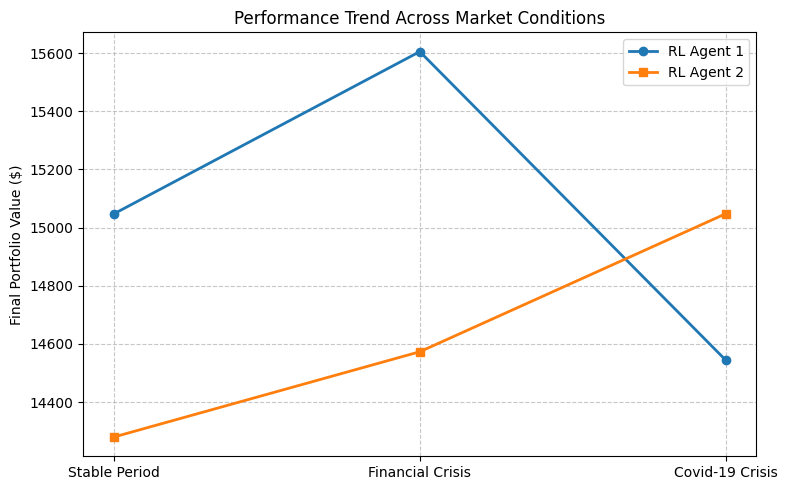

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(periods, agent1, marker='o', label='RL Agent 1', linewidth=2)
plt.plot(periods, agent2, marker='s', label='RL Agent 2', linewidth=2)
plt.ylabel("Final Portfolio Value ($)")
plt.title("Performance Trend Across Market Conditions")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()